   Age  Sex  Chest pain type   BP  Cholesterol  FBS over 120  EKG results  \
0   70    1                4  130          322             0            2   
1   67    0                3  115          564             0            2   
2   57    1                2  124          261             0            0   
3   64    1                4  128          263             0            0   
4   74    0                2  120          269             0            2   

   Max HR  Exercise angina  ST depression  Slope of ST  \
0     109                0            2.4            2   
1     160                0            1.6            2   
2     141                0            0.3            1   
3     105                1            0.2            2   
4     121                1            0.2            1   

   Number of vessels fluro  Thallium Heart Disease  
0                        3         3      Presence  
1                        0         7       Absence  
2                        0   

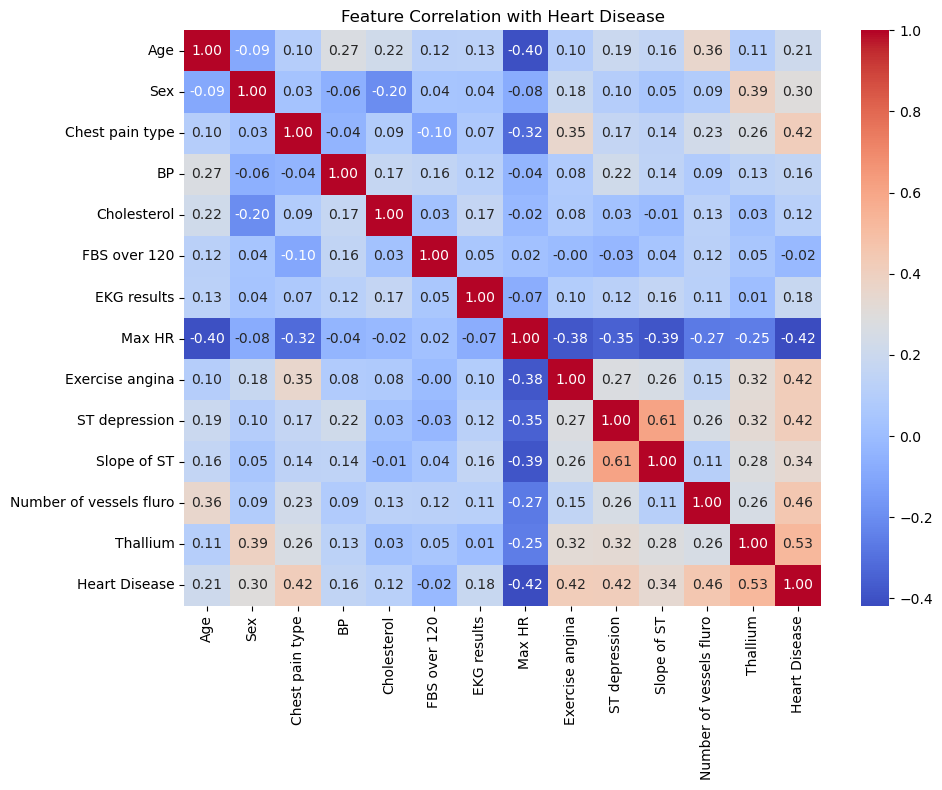


Correlation with target:
 Heart Disease              1.000000
Thallium                   0.525020
Number of vessels fluro    0.455336
Exercise angina            0.419303
ST depression              0.417967
Chest pain type            0.417436
Slope of ST                0.337616
Sex                        0.297721
Age                        0.212322
EKG results                0.182091
BP                         0.155383
Cholesterol                0.118021
FBS over 120              -0.016319
Max HR                    -0.418514
Name: Heart Disease, dtype: float64

Class balance:
 Heart Disease
0    0.555556
1    0.444444
Name: proportion, dtype: float64

After scaling - mean & std:
                Age           Sex  Chest pain type            BP   Cholesterol  \
mean -3.371788e-16 -6.990293e-17     2.446603e-16 -1.284980e-16 -1.027984e-17   
std   1.002323e+00  1.002323e+00     1.002323e+00  1.002323e+00  1.002323e+00   

      FBS over 120   EKG results        Max HR  Exercise angina  \


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# ---------------------------------------------------
# 1) Data load karo
# ---------------------------------------------------
df = pd.read_csv('heart.csv')
print(df.head())
print(df.info())

# ---------------------------------------------------
# 2) Missing values / duplicates check
# ---------------------------------------------------
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# ---------------------------------------------------
# 3) Target column encode karo (Absence/Presence -> 0/1)
# ---------------------------------------------------
enco = LabelEncoder()
df["Heart Disease"] = enco.fit_transform(df['Heart Disease'])
print("\nClasses:", enco.classes_)   # confirm which is 0 and which is 1

# ---------------------------------------------------
# 4) EDA - correlation dekh lo (kaunse features zyada important)
# ---------------------------------------------------
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation with Heart Disease")
plt.tight_layout()
plt.show()

print("\nCorrelation with target:\n",
      df.corr(numeric_only=True)["Heart Disease"].sort_values(ascending=False))

# ---------------------------------------------------
# 5) Features (X) aur target (y) — SAB columns rakho
# ---------------------------------------------------
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

# ---------------------------------------------------
# 6) Class balance check
# ---------------------------------------------------
print("\nClass balance:\n", y.value_counts(normalize=True))

# ---------------------------------------------------
# 7) Train-test split
# ---------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------------------------------
# 8) Feature Scaling (SABSE ZAROORI STEP)
# ---------------------------------------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform train pe
X_test_scaled = scaler.transform(X_test)          # sirf transform test pe

# check: scaling sahi hui ya nahi (mean~0, std~1)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
print("\nAfter scaling - mean & std:\n",
      X_train_scaled_df.describe().loc[['mean', 'std']])

# ---------------------------------------------------
# 9) Model train karo
# ---------------------------------------------------
logr = LogisticRegression(max_iter=1000)
logr.fit(X_train_scaled, y_train)

# ---------------------------------------------------
# 10) Predict aur evaluate
# ---------------------------------------------------
y_pred = logr.predict(X_test_scaled)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
# print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# # ---------------------------------------------------
# # 11) Cross-validation (chota dataset hai, reliable check ke liye)
# # ---------------------------------------------------
# X_scaled_full = scaler.fit_transform(X)
# cv_scores = cross_val_score(LogisticRegression(max_iter=1000), X_scaled_full, y, cv=5)
# print("\n5-fold CV accuracy:", cv_scores.mean(), "+/-", cv_scores.std())

# # ---------------------------------------------------
# # 12) Feature importance (coefficients)
# # ---------------------------------------------------
# coeffs = pd.Series(logr.coef_[0], index=X.columns).sort_values()
# plt.figure(figsize=(8, 6))
# coeffs.plot(kind="barh", color="steelblue")
# plt.title("Feature Impact on Heart Disease Prediction")
# plt.xlabel("Coefficient (scaled)")
# plt.tight_layout()
# plt.show()

# print("\nFeature coefficients:\n", coeffs)